# Exploring Zigzag Persistence on Neural Response Grids

This notebook explores zigzag persistence diagrams from 3D neural activity grids
(shape `15×15×10×n_frames`) recorded during video stimuli presentation.

**Goals:**
1. Load and inspect trial data from multiple mice
2. Understand the activation distribution and compute percentile-based thresholds
3. Run zigzag persistence across a range of `p_active` percentiles (10–90)
4. Visualize and compare persistence diagrams across thresholds
5. Assess stability and informativeness to select the optimal threshold


In [ ]:
import os
import glob
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from zztop import (
    run_cubical_zigzag,
    run_cubical_persistence_gpu,
    gpu_available,
    gpu_supports_3d,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})



In [31]:
FIGURES_DIR = Path("../figure_regeneration").resolve()/"output_figures"
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Data loading and inspection

In [2]:
# DATA_ROOT = Path(
#     "/orfeo/scratch/area/ygardinazzi/sensorium_2026/derivatives/"
#     "grid-15x15x10_norm-by_minmax"
# )
DATA_ROOT = Path("/home/anaflo/Documenti/MDMC/sensorium/derivatives/grid-15x15x10_norm-by_minmax")

# List all mice
mice = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(mice)} mice:")
for m in mice:
    n_trials = len(list((DATA_ROOT / m / "trials").glob("*.npy")))
    print(f"  {m}: {n_trials} trials")

Found 10 mice:
  dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce: 720 trials
  dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce: 704 trials
  dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce: 729 trials
  dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce: 713 trials
  dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce: 723 trials
  dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20: 445 trials
  dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20: 420 trials
  dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20: 444 trials
  dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20: 461 trials
  dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20: 450 trials


In [3]:
# Pick a reference mouse and load a handful of trials
REF_MOUSE = mice[0]
trial_files = sorted((DATA_ROOT / REF_MOUSE / "trials").glob("*.npy"))

# Sample ~8 trials spread across the list
rng = np.random.default_rng(42)
N_SAMPLE = 8
sample_idx = np.linspace(0, len(trial_files) - 1, N_SAMPLE, dtype=int)
sample_files = [trial_files[i] for i in sample_idx]

sample_data = {}
for f in sample_files:
    data = np.load(f)
    trial_name = f.stem.split("_trial-")[-1]
    sample_data[f"trial-{trial_name}"] = data
    print(f"  {f.name}: shape={data.shape}, range=[{data.min():.4f}, {data.max():.4f}]")

print(f"\nLoaded {len(sample_data)} trials from mouse: {REF_MOUSE}")

  grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-0.npy: shape=(15, 15, 10, 300), range=[0.0000, 0.5651]
  grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-194.npy: shape=(15, 15, 10, 300), range=[0.0000, 0.3338]
  grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-29.npy: shape=(15, 15, 10, 240), range=[0.0000, 0.5065]
  grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-385.npy: shape=(15, 15, 10, 300), range=[0.0000, 0.4971]
  grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-478.npy: shape=(15, 15, 10, 300), range=[0.0000, 0.4056]
  grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-571.npy: shape=(15, 15, 10, 300), range=[0.0000, 0.4967]
  grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744ede

## 2. Activation distribution and threshold computation

The `threshold` parameter in `run_cubical_zigzag` controls which higher-dimensional
cubical cells are "active" at each frame. Internally, gird values are **negated**
before being passed to GUDHI, so a cell with activation $a$ gets filtration value $-a$.
A cell is active if its filtration value $< \text{threshold}$, i.e. if $-a < \text{threshold}$,
i.e. if $a > -\text{threshold}$.

We define `p_active` as a percentile of the positive activation values across all
voxels and frames in a trial. Lower `p_active` → lower threshold → more cells active
→ richer topology.

In [4]:
def compute_threshold(data, p_active):
    """Compute the activation threshold for a given p_active percentile.
    
    The threshold is the negative of the p_active-th percentile of positive
    activation values. This matches zz-top's internal convention where grid
    values are negated.
    
    Parameters
    ----------
    data : np.ndarray
        Grid data of shape (N1, ..., Nd, n_frames).
    p_active : float
        Percentile (0-100) of positive activations to use as threshold.
        Higher p_active → more cells active → richer topology.
    
    Returns
    -------
    float
        Threshold value to pass to run_cubical_zigzag.
    """
    positive_vals = data[data > 0].ravel()
    if len(positive_vals) == 0:
        return 0.0
    activation_cutoff = np.percentile(positive_vals, p_active)
    return -activation_cutoff  # Negate to match zz-top convention

In [14]:
def plot_activation_distribution(ax, data, p_active_values, name=""):

    pos_vals = data[data > 0].ravel()
    ax.hist(pos_vals, bins=200, density=True, alpha=0.7, color="steelblue")
    # Mark percentile thresholds
    for p in p_active_values:
        pval = np.percentile(pos_vals, p)
        ax.axvline(pval, color="red", linestyle="--", alpha=0.6, linewidth=1)
        ax.text(pval, ax.get_ylim()[1] * 0.9, f"p{p}", fontsize=7, color="red",
                ha="center", rotation=45)
    # gplot the mean as well
    avg = np.mean(data)
    ax.axvline(avg, color="green", linestyle="--", alpha=0.6, linewidth=1)
    ax.text(avg, ax.get_ylim()[1] * 0.8, "mean", fontsize=7, color="green",
        ha="center", rotation=45)

    ax.set_xlim(0, np.percentile(pos_vals, 95))  # Focus on main distribution
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Activation")


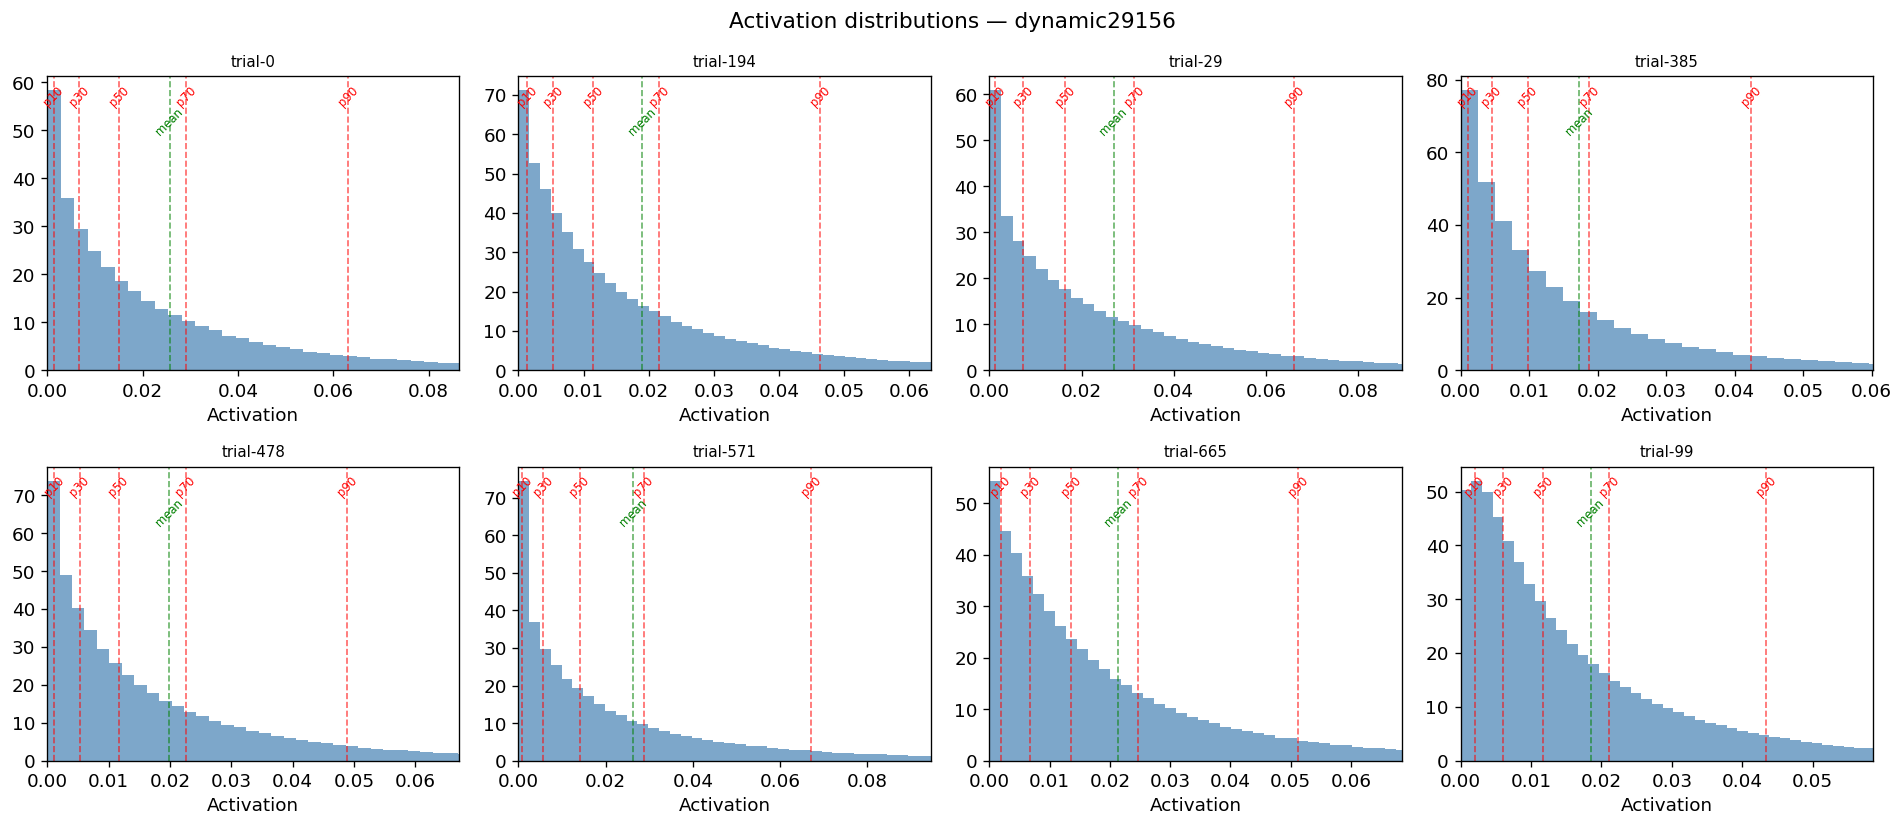

In [ ]:
# Visualize the activation distribution for a few trials
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
p_active_values = [10, 30, 50, 70, 90]

for ax, (name, data) in zip(axes.flat, sample_data.items()):

    plot_activation_distribution(ax, data, p_active_values, name=name)


fig.suptitle(f"Activation distributions — {REF_MOUSE.split('-')[0]}", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Compute thresholds for all sampled trials at each p_active
threshold_table = {}
for p in p_active_values:
    thresholds = []
    for name, data in sample_data.items():
        t = compute_threshold(data, p)
        thresholds.append(t)
    threshold_table[p] = thresholds
    mean_t = np.mean(thresholds)
    std_t = np.std(thresholds)
    print(f"  p_active={p:3d}: threshold = {mean_t:.6f} ± {std_t:.6f}")

print("\nNote: threshold is negative (matches negated GUDHI convention).")
print("A more negative threshold → higher activation cutoff → fewer active cells.")

  p_active= 10: threshold = -0.001346 ± 0.000367
  p_active= 30: threshold = -0.005961 ± 0.000844
  p_active= 50: threshold = -0.012972 ± 0.002050
  p_active= 70: threshold = -0.024775 ± 0.004258
  p_active= 90: threshold = -0.053604 ± 0.009645

Note: threshold is negative (matches negated GUDHI convention).
A more negative threshold → higher activation cutoff → fewer active cells.


## 3. Zigzag persistence across thresholds

We run `run_cubical_zigzag` for a subset of trials at each `p_active` value.
This is the core experiment: how does the choice of threshold affect the
resulting persistence diagrams?

In [9]:
# Run zigzag persistence for each trial × each p_active
# Use only 3 trials to keep compute time reasonable
N_ZZ_TRIALS = 3
zz_trial_names = list(sample_data.keys())[:N_ZZ_TRIALS]

# run_cubical_zigzag returns (dim, birth_frame, death_frame) directly
zz_results = {}  # zz_results[p_active][trial_name] = bars
zz_nframes = {}  # zz_nframes[trial_name] = n_frames

for p in p_active_values:
    zz_results[p] = {}
    for name in zz_trial_names:
        data = sample_data[name]
        threshold = compute_threshold(data, p)
        nf = data.shape[-1]
        zz_nframes[name] = nf
        
        t0 = time.time()
        bars = run_cubical_zigzag(data, threshold=threshold)
        elapsed = time.time() - t0
        
        zz_results[p][name] = bars
        
        # Count bars per dimension
        dims = [b[0] for b in bars]
        for d in sorted(set(dims)):
            n_d = sum(1 for x in dims if x == d)
            print(f"  p_active={p}, {name}, dim {d}: {n_d} bars")
        print(f"    → {len(bars)} total bars, {nf} frames, computed in {elapsed:.1f}s")
    print()

  p_active=10, trial-0, dim 0: 14988 bars
  p_active=10, trial-0, dim 1: 60792 bars
  p_active=10, trial-0, dim 2: 17451 bars
  p_active=10, trial-0, dim 3: 17313 bars
    → 110544 total bars, 300 frames, computed in 140.5s
  p_active=10, trial-194, dim 0: 15850 bars
  p_active=10, trial-194, dim 1: 65303 bars
  p_active=10, trial-194, dim 2: 18622 bars
  p_active=10, trial-194, dim 3: 18500 bars
    → 118275 total bars, 300 frames, computed in 195.5s
  p_active=10, trial-29, dim 0: 12369 bars
  p_active=10, trial-29, dim 1: 44640 bars
  p_active=10, trial-29, dim 2: 11999 bars
  p_active=10, trial-29, dim 3: 11934 bars
    → 80942 total bars, 240 frames, computed in 69.8s

  p_active=30, trial-0, dim 0: 25926 bars
  p_active=30, trial-0, dim 1: 95521 bars
  p_active=30, trial-0, dim 2: 20699 bars
  p_active=30, trial-0, dim 3: 20634 bars
    → 162780 total bars, 300 frames, computed in 173.8s
  p_active=30, trial-194, dim 0: 26512 bars
  p_active=30, trial-194, dim 1: 96566 bars
  p_a

## 4. Visualize persistence diagrams

In [17]:
def plot_persistence_diagram(bars, ax, title="", max_dim=2, n_frames=None):
    """Plot a persistence diagram (birth vs death) from zigzag barcode.
    
    bars should contain frame-indexed birth/death values.
    """
    colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}
    labels = {0: "H₀ (components)", 1: "H₁ (loops)", 2: "H₂ (voids)"}
    
    for dim in range(max_dim + 1):
        pts = [(b, d) for (dd, b, d) in bars if dd == dim and d != float("inf")]
        if pts:
            births, deaths = zip(*pts)
            ax.scatter(births, deaths, s=8, alpha=0.5, c=colors.get(dim, "gray"),
                      label=f"{labels.get(dim, f'H_{dim}')} ({len(pts)})")
    
    # Diagonal line
    max_val = n_frames if n_frames else max(ax.get_xlim()[1], ax.get_ylim()[1], 1)
    ax.plot([0, max_val], [0, max_val], "k--", alpha=0.3, lw=0.8)
    if n_frames:
        ax.set_xlim(-1, n_frames)
        ax.set_ylim(-1, n_frames)
    ax.set_xlabel("Birth (frame)")
    ax.set_ylabel("Death (frame)")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=9, loc="lower right")
    ax.set_aspect("equal")

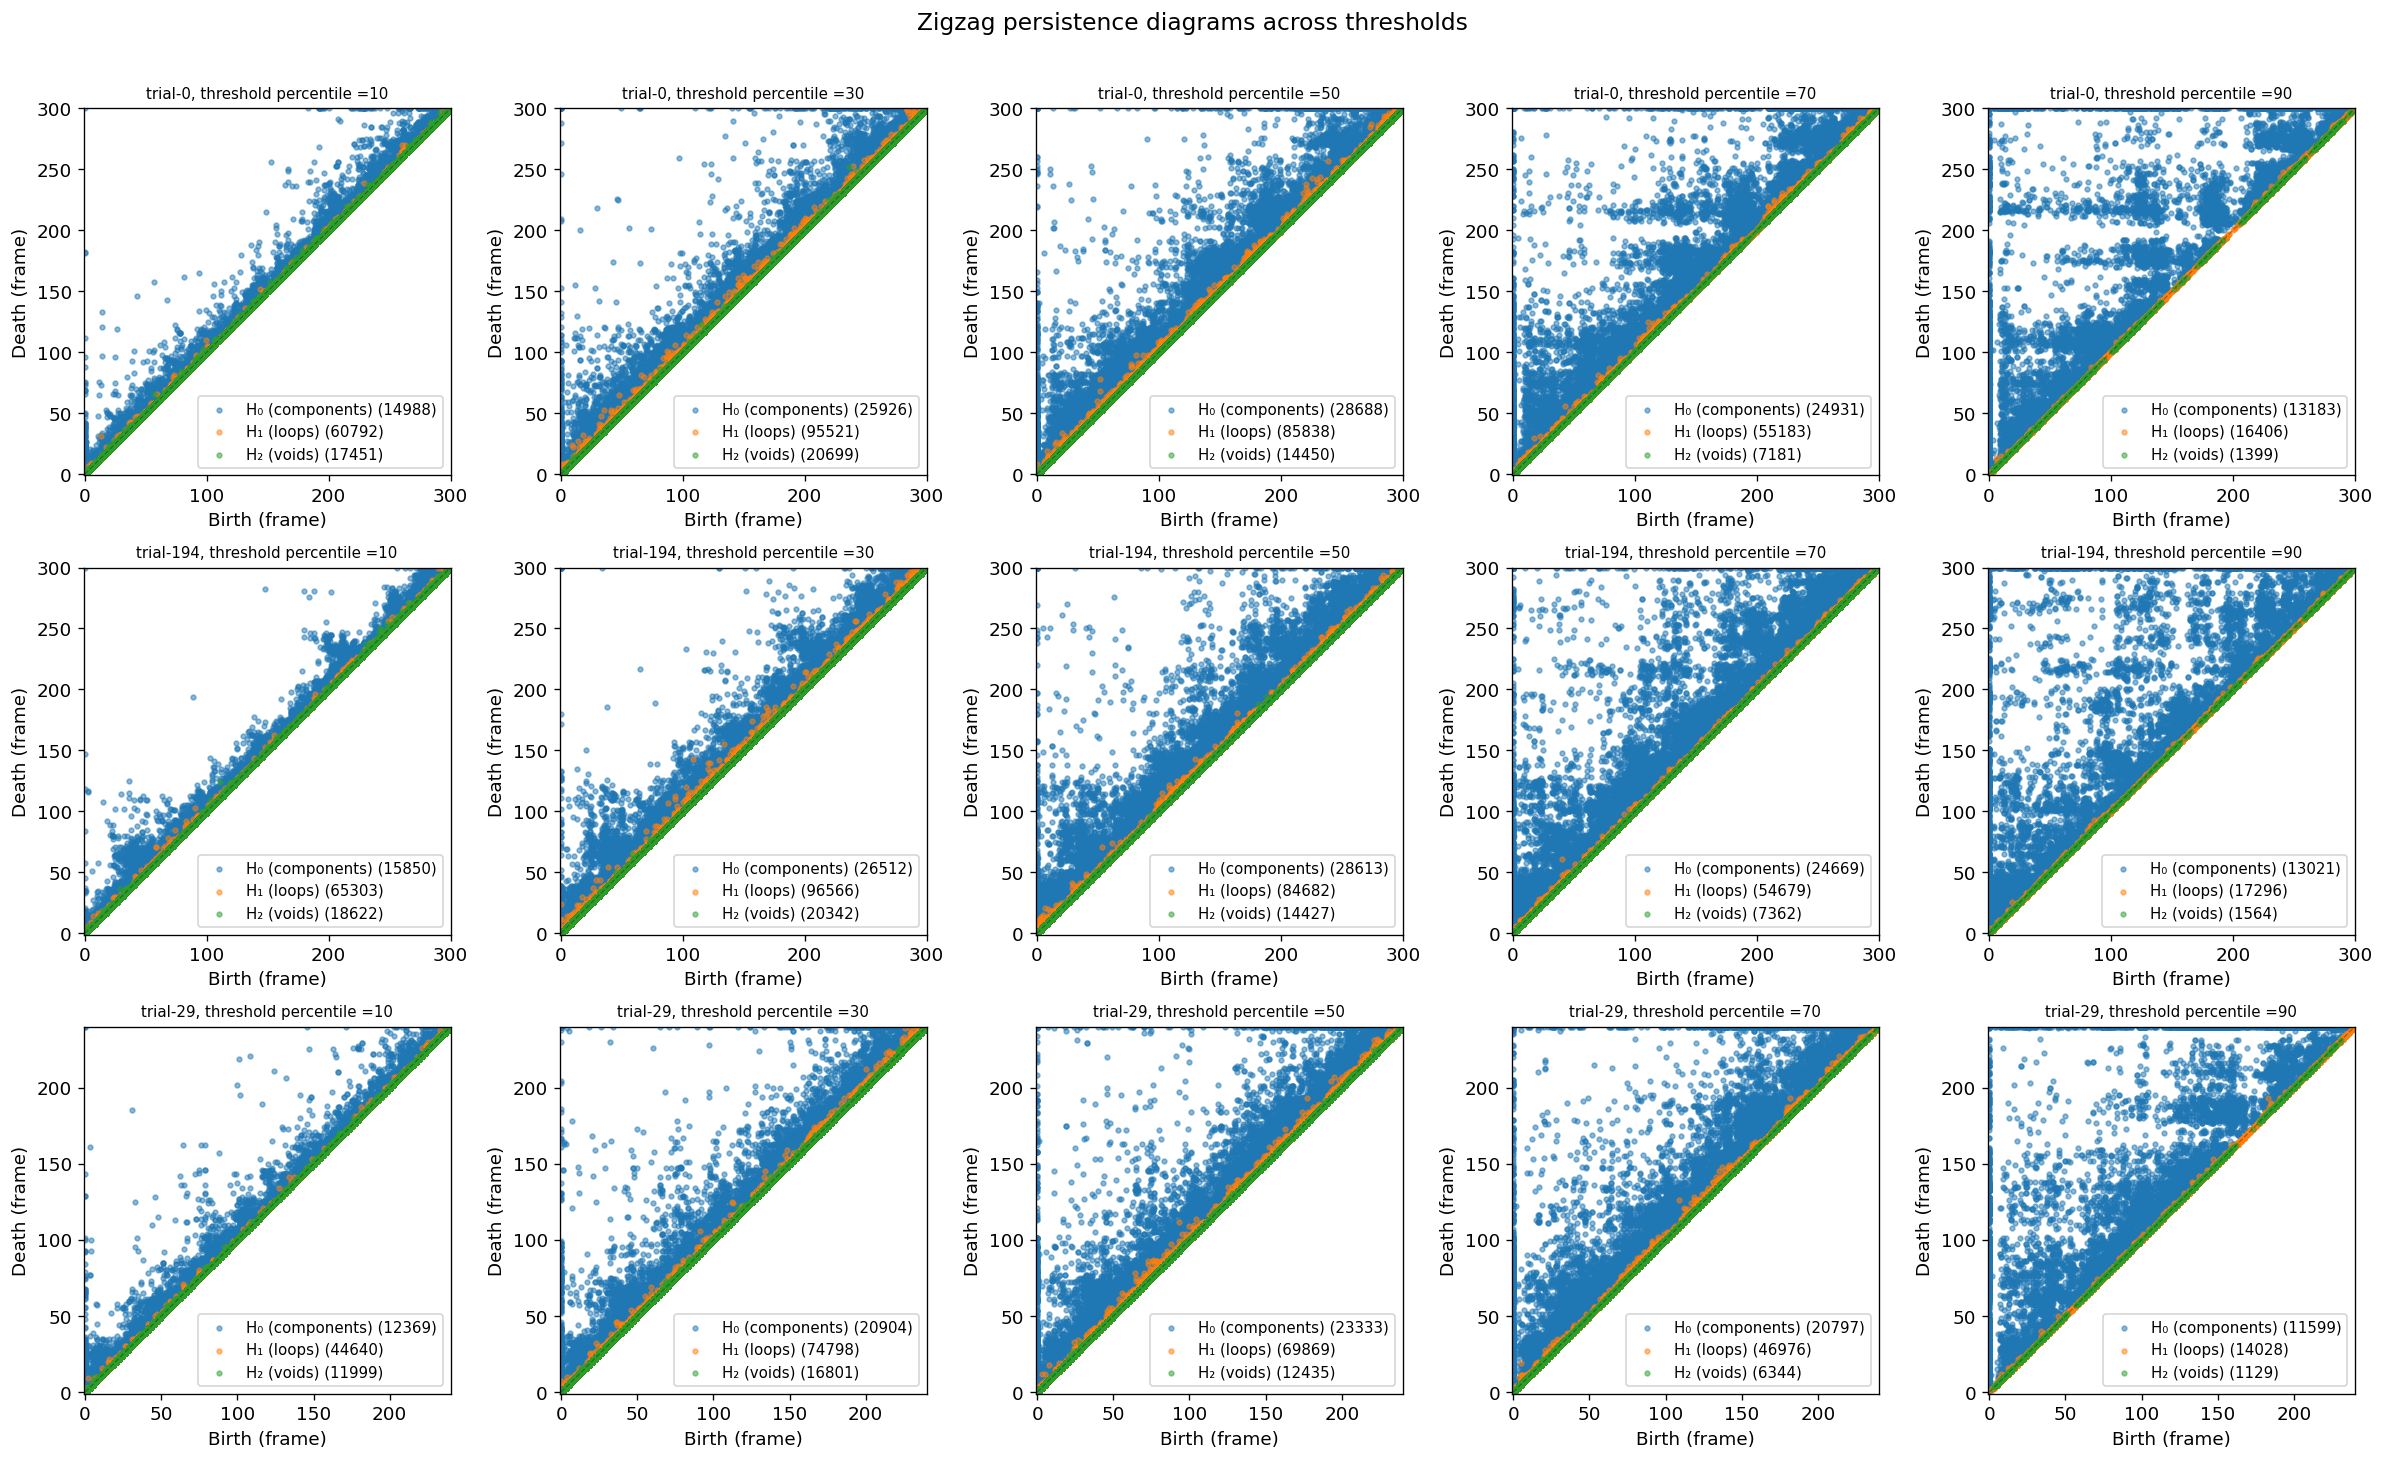

In [21]:
# Persistence diagrams: one row per trial, one column per p_active
fig, axes = plt.subplots(
    N_ZZ_TRIALS, len(p_active_values),
    figsize=(4 * len(p_active_values), 4 * N_ZZ_TRIALS),
    squeeze=False,
)

for i, name in enumerate(zz_trial_names):
    nf = zz_nframes[name]
    for j, p in enumerate(p_active_values):
        bars = zz_results[p][name]
        plot_persistence_diagram(bars, axes[i, j],
                                 title=f"{name}, threshold percentile ={p}", n_frames=nf)

fig.suptitle("Zigzag persistence diagrams across thresholds", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

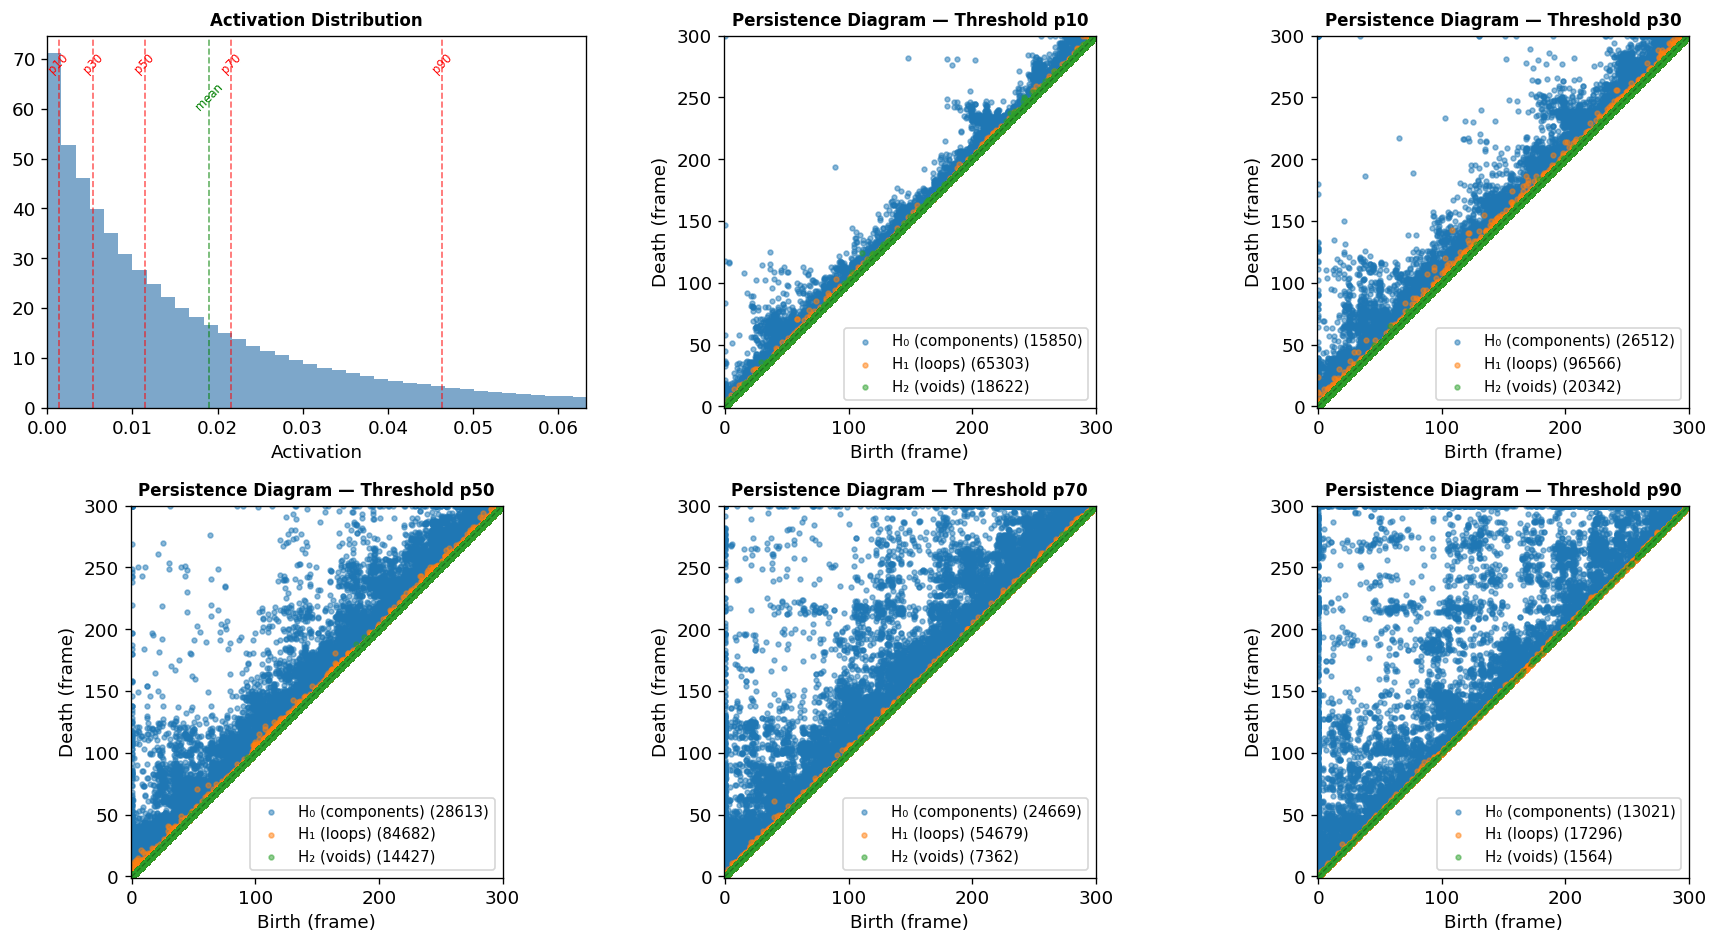

In [32]:
trial_name = 'trial-194'
trial_data = sample_data[trial_name]
nf = trial_data.shape[-1]

# Create figure: 1 subplot for activation distribution + 5 for persistence diagrams
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flat

# Plot 1: Activation distribution for trial 194
ax = axes_flat[0]
plot_activation_distribution(ax, trial_data, p_active_values, name=f"activation distribution")
ax.set_title("Activation Distribution", fontsize=10, fontweight="bold")

# Plots 2-6: Persistence diagrams from pre-computed zz_results for first sample trial
# (to show the effect of threshold on the already-computed persistence data)
nf_sample = zz_nframes[trial_name]
for idx, p in enumerate(p_active_values):
    ax = axes_flat[idx + 1]
    bars = zz_results[p][trial_name]
    plot_persistence_diagram(bars, ax, title=f"", n_frames=nf_sample)
    ax.set_title(f"Persistence Diagram — Threshold p{p}", fontsize=10, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"zigzag_persistence_{trial_name}.png", dpi=300, bbox_inches="tight")
plt.show()


In [37]:
def plot_persistence_barcode(
    bars,
    ax,
    title="",
    max_dim=2,
    n_frames=None,
    max_bars_per_dim=220,
    group_height=1.0,
    group_gap=0.22,
):
    """Plot a readable persistence barcode from zigzag bars.

    To avoid severe overplotting with very large bar counts, each homology group
    is downsampled to the longest bars (up to max_bars_per_dim).
    """
    colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

    ytick_pos, ytick_labels = [], []
    y_base = 0.0

    for dim in range(max_dim + 1):
        dim_bars = [(b, d) for (dd, b, d) in bars if dd == dim and d != float("inf")]
        if not dim_bars:
            continue

        # Sort by persistence (longest first), then keep a readable subset.
        dim_bars.sort(key=lambda x: (x[1] - x[0]), reverse=True)
        n_total = len(dim_bars)
        shown = dim_bars[:max_bars_per_dim]
        n_shown = len(shown)

        # Evenly spread bars inside this group's vertical band.
        if n_shown == 1:
            y_positions = np.array([y_base + group_height / 2])
        else:
            y_positions = np.linspace(y_base, y_base + group_height, n_shown)

        for (b, d), y in zip(shown, y_positions):
            ax.plot([b, d], [y, y], color=colors.get(dim, "gray"), linewidth=1.0, alpha=0.85)

        ytick_pos.append(y_base + group_height / 2)
        suffix = "" if n_shown == n_total else f", showing {n_shown}"
        ytick_labels.append(f"H{dim} ({n_total}{suffix})")

        y_base += group_height + group_gap

    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_labels, fontsize=8)
    ax.set_xlabel("Frame")
    if n_frames:
        ax.set_xlim(-1, n_frames)
    ax.set_title(title, fontsize=9)
    ax.invert_yaxis()  # Keep H0 on top for easier reading across rows.


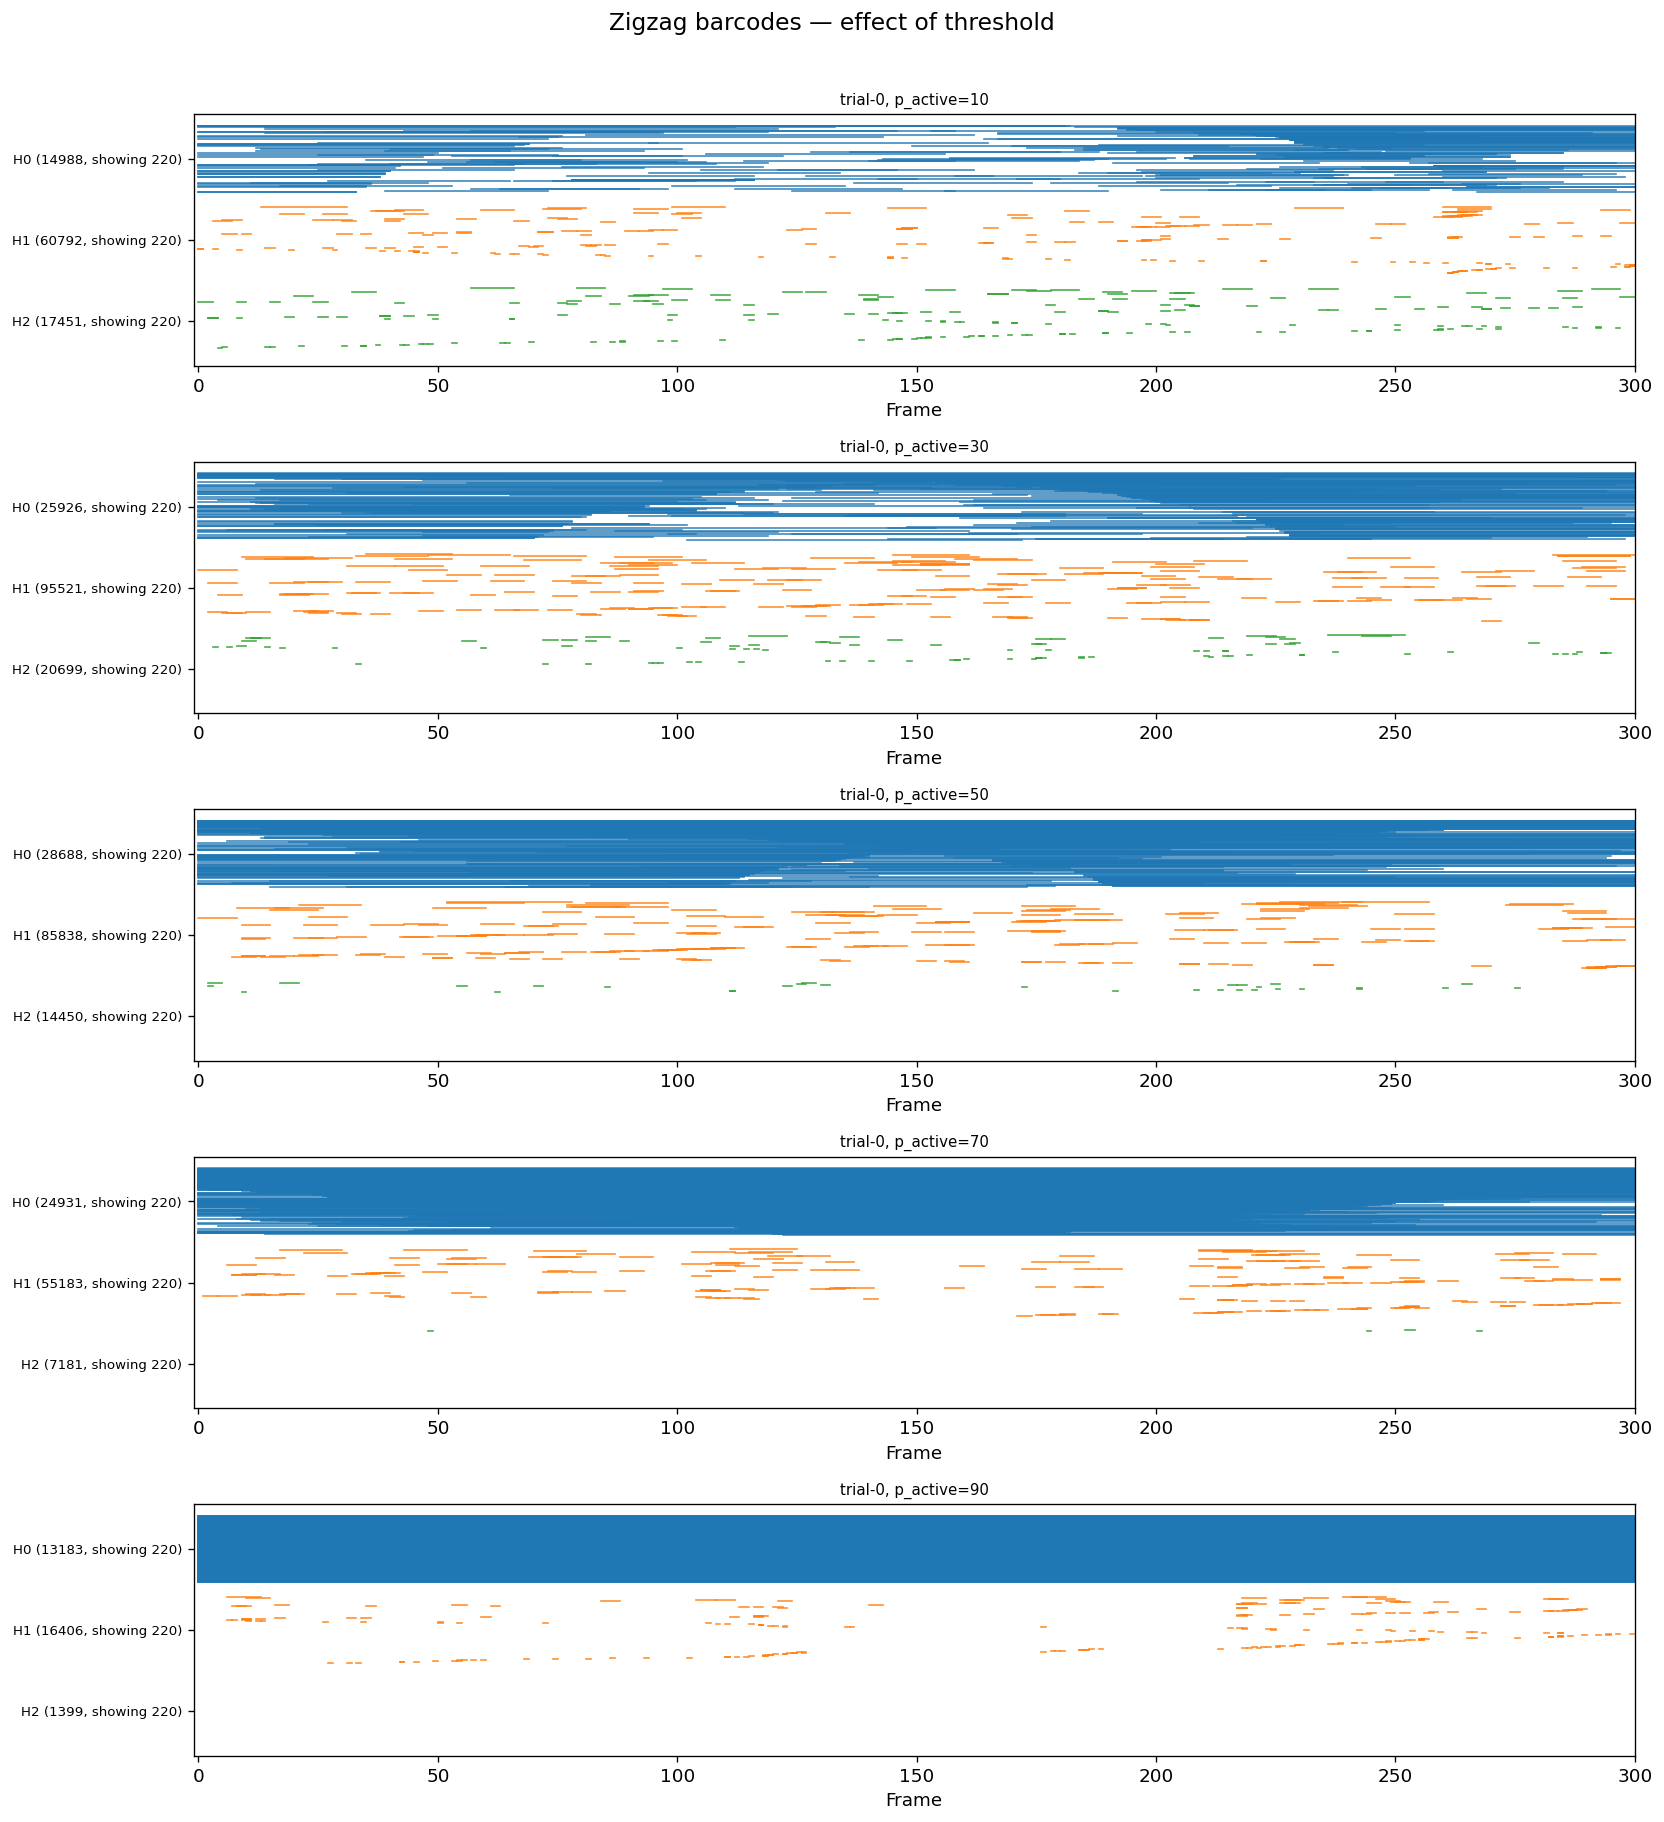

In [38]:
# Barcode visualization for one trial across thresholds
ref_trial = zz_trial_names[0]
nf = zz_nframes[ref_trial]
fig, axes = plt.subplots(len(p_active_values), 1,
                          figsize=(14, 3 * len(p_active_values)))

for ax, p in zip(axes, p_active_values):
    bars = zz_results[p][ref_trial]
    plot_persistence_barcode(bars, ax, title=f"{ref_trial}, p_active={p}",
                             n_frames=nf)

fig.suptitle("Zigzag barcodes — effect of threshold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Stability analysis: choosing the optimal threshold

We now quantify how diagram properties change with `p_active` to find the
"sweet spot" — the threshold that produces informative, stable, and
discriminative diagrams.

In [39]:
def barcode_stats(bars, max_dim=2):
    """Compute summary statistics from a zigzag barcode."""
    stats = {}
    for dim in range(max_dim + 1):
        finite_bars = [(b, d) for (dd, b, d) in bars if dd == dim and d != float("inf")]
        if not finite_bars:
            stats[dim] = {
                "n_bars": 0, "mean_pers": 0, "median_pers": 0,
                "total_pers": 0, "max_pers": 0, "std_pers": 0,
            }
            continue
        persistences = [d - b for b, d in finite_bars]
        stats[dim] = {
            "n_bars": len(finite_bars),
            "mean_pers": np.mean(persistences),
            "median_pers": np.median(persistences),
            "total_pers": np.sum(persistences),
            "max_pers": np.max(persistences),
            "std_pers": np.std(persistences),
        }
    return stats

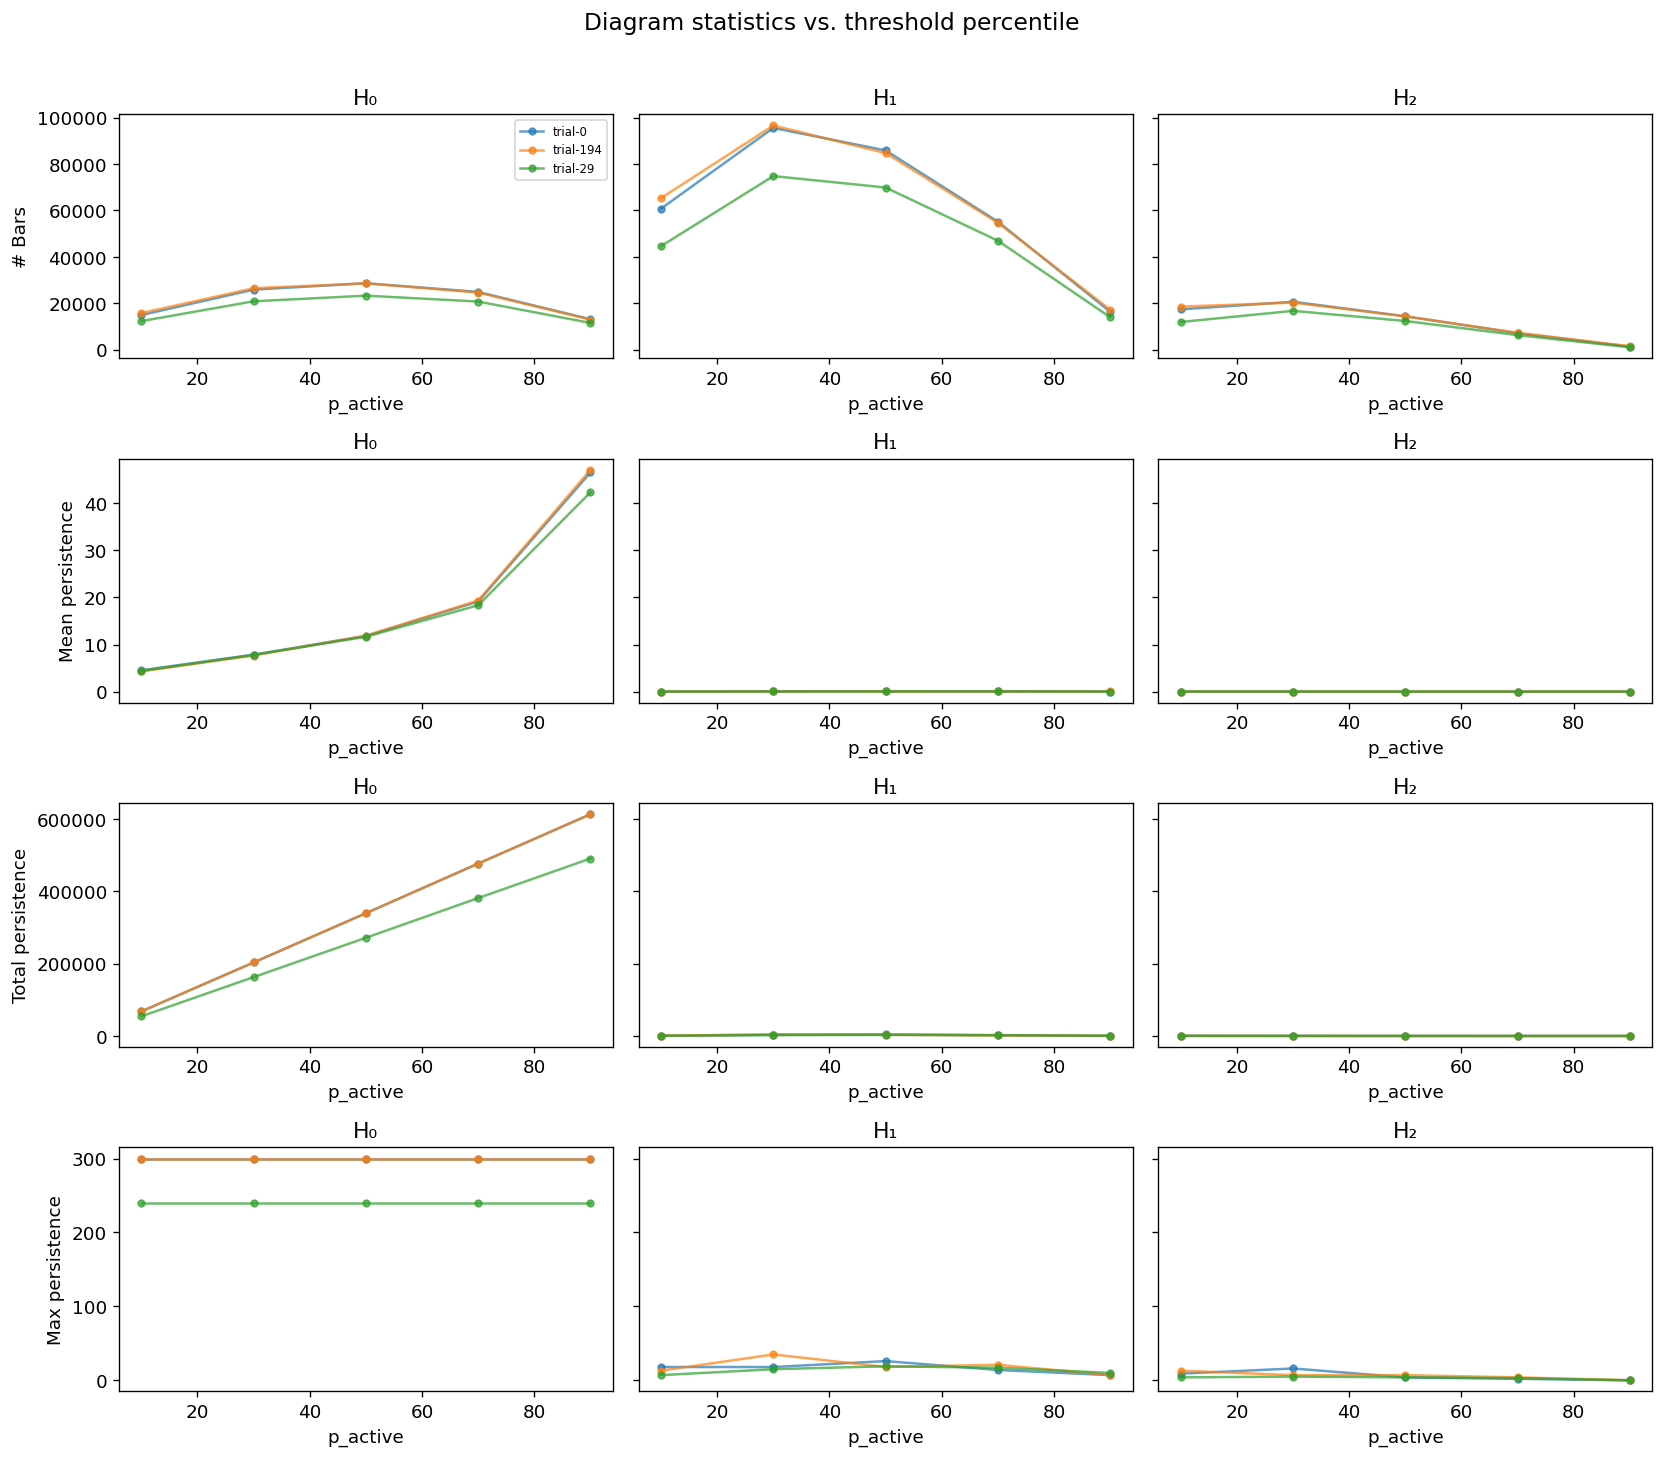

In [40]:
# Collect statistics across trials and thresholds
all_stats = {}  # all_stats[p_active] = list of stats dicts (one per trial)

for p in p_active_values:
    all_stats[p] = []
    for name in zz_trial_names:
        bars = zz_results[p][name]
        s = barcode_stats(bars)
        all_stats[p].append(s)

# Plot summary statistics as a function of p_active
metrics = ["n_bars", "mean_pers", "total_pers", "max_pers"]
metric_labels = ["# Bars", "Mean persistence", "Total persistence", "Max persistence"]

fig, axes = plt.subplots(len(metrics), 3, figsize=(14, 3 * len(metrics)), sharey="row")
dim_labels = ["H₀", "H₁", "H₂"]

for row, (metric, mlabel) in enumerate(zip(metrics, metric_labels)):
    for dim in range(3):
        ax = axes[row, dim]
        for t_idx, name in enumerate(zz_trial_names):
            values = [all_stats[p][t_idx][dim][metric] for p in p_active_values]
            ax.plot(p_active_values, values, "o-", alpha=0.7, label=name, markersize=4)
        ax.set_xlabel("p_active")
        if dim == 0:
            ax.set_ylabel(mlabel)
        ax.set_title(f"{dim_labels[dim]}")
        if row == 0 and dim == 0:
            ax.legend(fontsize=7)

fig.suptitle("Diagram statistics vs. threshold percentile", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# Coefficient of variation (CV) across trials — measures inter-trial stability
print("Coefficient of Variation (CV) across trials — lower = more stable:\n")
print(f"{'p_active':>10} | {'Metric':>18} | {'H0 CV':>8} | {'H1 CV':>8} | {'H2 CV':>8}")
print("-" * 70)

for p in p_active_values:
    for metric in ["n_bars", "total_pers"]:
        cvs = []
        for dim in range(3):
            vals = [all_stats[p][t_idx][dim][metric] for t_idx in range(N_ZZ_TRIALS)]
            mean_v = np.mean(vals)
            std_v = np.std(vals)
            cv = std_v / mean_v if mean_v > 0 else float("nan")
            cvs.append(cv)
        print(f"{p:>10} | {metric:>18} | {cvs[0]:>8.3f} | {cvs[1]:>8.3f} | {cvs[2]:>8.3f}")
    print()

Coefficient of Variation (CV) across trials — lower = more stable:

  p_active |             Metric |    H0 CV |    H1 CV |    H2 CV
----------------------------------------------------------------------
        10 |             n_bars |    0.103 |    0.156 |    0.180
        10 |         total_pers |    0.101 |    0.314 |    0.336

        30 |             n_bars |    0.103 |    0.113 |    0.091
        30 |         total_pers |    0.101 |    0.228 |    0.182

        50 |             n_bars |    0.093 |    0.091 |    0.069
        50 |         total_pers |    0.101 |    0.143 |    0.113

        70 |             n_bars |    0.081 |    0.072 |    0.064
        70 |         total_pers |    0.101 |    0.107 |    0.683

        90 |             n_bars |    0.056 |    0.087 |    0.131
        90 |         total_pers |    0.101 |    0.183 |      nan



## 6. Cross-mouse consistency

Check whether the optimal `p_active` generalizes across mice, or whether
each mouse needs its own threshold.

In [ ]:
# Load one trial from each of 3 different mice
cross_mouse_data = {}
cross_mouse_names = [mice[0], mice[1], mice[2]]  

for m in cross_mouse_names:
    trials = sorted((DATA_ROOT / m / "trials").glob("*.npy"))
    # Pick a trial in the middle
    trial_file = trials[len(trials) // 2]
    data = np.load(trial_file)
    short_name = m.split("-")[0] + m.split("-")[1]
    cross_mouse_data[short_name] = data
    print(f"  {m[:30]}...: shape={data.shape}")

In [ ]:
# Run zigzag persistence at each p_active for each mouse
cross_mouse_results = {}  # cross_mouse_results[mouse_name][p_active] = bars (frame-indexed)

for mname, data in cross_mouse_data.items():
    cross_mouse_results[mname] = {}
    nf = data.shape[-1]
    for p in p_active_values:
        threshold = compute_threshold(data, p)
        t0 = time.time()
        bars = run_cubical_zigzag(data, threshold=threshold)
        elapsed = time.time() - t0
        cross_mouse_results[mname][p] = bars
        n_total = len([b for b in bars if b[2] != float("inf")])
        print(f"  {mname}, p_active={p}: {n_total} finite bars, {nf} frames ({elapsed:.1f}s)")
    print()

In [ ]:
# Compare cross-mouse: total persistence and bar counts across p_active
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for mname in cross_mouse_results:
    for dim in range(3):
        n_bars_list = []
        total_pers_list = []
        for p in p_active_values:
            bars = cross_mouse_results[mname][p]
            s = barcode_stats(bars)
            n_bars_list.append(s[dim]["n_bars"])
            total_pers_list.append(s[dim]["total_pers"])
        axes[0, dim].plot(p_active_values, n_bars_list, "o-", label=mname, markersize=5)
        axes[1, dim].plot(p_active_values, total_pers_list, "o-", label=mname, markersize=5)

for dim in range(3):
    axes[0, dim].set_title(f"H{dim} — # Bars")
    axes[1, dim].set_title(f"H{dim} — Total persistence")
    axes[0, dim].set_xlabel("p_active")
    axes[1, dim].set_xlabel("p_active")

axes[0, 0].legend(fontsize=8)
fig.suptitle("Cross-mouse comparison of zigzag persistence", fontsize=14)
plt.tight_layout()
plt.show()